# Chapter 9 — Time-Varying Models: GARCH and DCC-GARCH

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion.

Two empirical findings from Chapters 2 and 3 were named-but-not-modelled: **vol clustering** (today's |return| predicts tomorrow's |return|) and **correlation regimes** (SPY/TLT correlation flipping sign in 2022). Chapter 9 is where these stop being deferred and start being modelled. **GARCH(1,1)** for σ<sub>t</sub>; **DCC-GARCH** for ρ<sub>t</sub>. The chapter introduces **Maximum Likelihood Estimation (MLE)** in passing — the only chapter that genuinely needs it.

## What we mean by "modeling time-varying second moments"

**RiskMetrics** — JP Morgan's 1996 technical document that made EWMA the industry-standard daily vol model — anchors the cheapest rung. Three rungs, each strictly more powerful and strictly more expensive:

| Model | Captures | Cost | Section |
|---|---|---|---|
| **EWMA** (RiskMetrics 1996) | Vol clustering only; no mean reversion | Closed form, no fitting; 1 hyperparameter | §2 |
| **GARCH(1,1)** | Vol clustering + mean reversion to long-run vol | MLE fit; 3 parameters | §3-5 |
| **DCC-GARCH** | Time-varying *correlations* | MLE on top of per-asset GARCHs | §6 |

> **Implementation note.** This chapter does *not* use the `arch` package — see README §1.

## 1. Setup

**SPY 20y daily log returns** for univariate work (same as Ch1-2). **SPY/TLT panel** for §6 DCC (same as Ch3). No new packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from statsmodels.tsa.stattools import acf

print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
import statsmodels, scipy
print(f"statsmodels  {statsmodels.__version__}")
print(f"scipy        {scipy.__version__}")

numpy        2.4.4
pandas       3.0.2
statsmodels  0.14.6
scipy        1.17.1


In [2]:
def to_series(x):
    if isinstance(x, pd.DataFrame): return x.squeeze() if x.shape[1] == 1 else x.iloc[:, 0]
    return x

# Univariate: SPY
spy_close = to_series(yf.download("SPY", period="20y", auto_adjust=True, progress=False)["Close"]).dropna()
spy_lr = np.log(spy_close / spy_close.shift(1)).dropna()
spy_lr.index = spy_lr.index.tz_localize(None) if spy_lr.index.tz else spy_lr.index

# Bivariate: SPY/TLT for §6
panel = yf.download(["SPY","TLT"], period="20y", auto_adjust=True, progress=False)["Close"].dropna()
panel.index = panel.index.tz_localize(None) if panel.index.tz else panel.index
panel_lr = np.log(panel / panel.shift(1)).dropna()

print(f"SPY N = {len(spy_lr):,}  date range: {spy_lr.index.min().date()} to {spy_lr.index.max().date()}")
print(f"Bivariate panel shape: {panel_lr.shape}")
spy_pct = (spy_lr * 100).values  # work in PERCENT for numerical stability

SPY N = 5,030  date range: 2006-05-08 to 2026-05-05
Bivariate panel shape: (5030, 2)


**Callback to Ch2 (vol clustering) and Ch3 (SPY/TLT regime flip).** Ch2's rolling-σ plot for SPY and Ch3's 60-day rolling SPY/TLT correlation are the *empirical motivations* for this chapter — the patterns are real; what's new is *modelling* the dynamics.

## 2. EWMA — the cheapest answer

EWMA is the **exponentially-weighted moving average** of squared returns. Closed-form recursion; no fitting; one hyperparameter (the decay).

### 2.1 The recursion

> σ²<sub>t</sub> = (1 − λ) · ε²<sub>t-1</sub> + λ · σ²<sub>t-1</sub>

where:
- *ε<sub>t-1</sub>* — yesterday's return shock. **Units:** decimal log return (or percent, whichever scale you're working in — be consistent).
- *σ²<sub>t</sub>* — today's variance forecast. **Units:** decimal-squared (or percent-squared).
- *λ* — decay parameter, in (0, 1). Larger = slower decay = more memory.
- *σ²<sub>0</sub>* — initialization, typically the sample variance over a warm-up window.

**RiskMetrics defaults:** λ = 0.94 (daily), λ = 0.97 (monthly). Decay half-life t<sub>1/2</sub> = log(2)/log(1/λ) ≈ 11 days at λ=0.94 and ~23 days at λ=0.97 (see README for derivation).

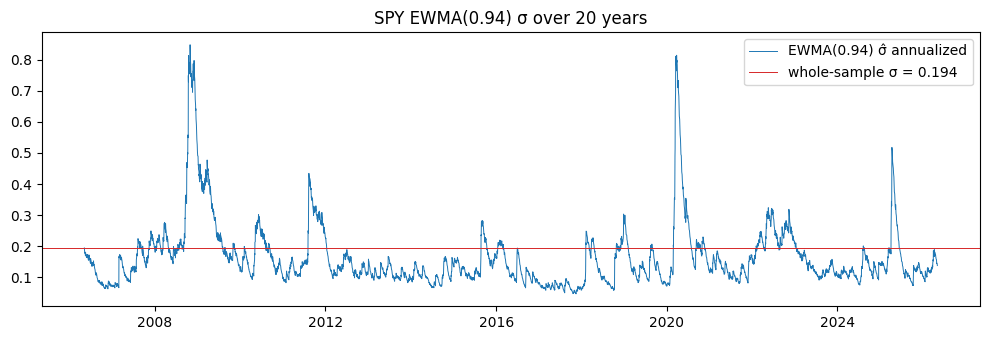

In [3]:
def ewma_sigma(x, lam=0.94):
    var = np.empty_like(x, dtype=float)
    var[0] = x.var()
    for t in range(1, len(x)):
        var[t] = (1 - lam) * x[t-1] ** 2 + lam * var[t-1]
    return np.sqrt(var)

ewma_sig_pct = ewma_sigma(spy_pct, lam=0.94)
ewma_sig = ewma_sig_pct / 100  # back to decimal/day
const_sigma = spy_lr.std()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(spy_lr.index, ewma_sig * np.sqrt(252), lw=0.7, label="EWMA(0.94) σ̂ annualized")
ax.axhline(const_sigma * np.sqrt(252), color="C3", lw=0.7, label=f"whole-sample σ = {const_sigma*np.sqrt(252):.3f}")
ax.set_title("SPY EWMA(0.94) σ over 20 years"); ax.legend(); fig.tight_layout(); plt.show()

**Reading the EWMA plot.** σ̂ jumps during stress (2008 GFC, March 2020 COVID) and decays smoothly during calm. Three named windows are visible:

- **GFC** (2007-10 → 2009-03) — sustained elevated regime; σ̂ peaks ~5× the whole-sample average.
- **COVID** (Feb-Apr 2020) — sharp spike, mean-reverts within months.
- **2022 selloff** — slower, smaller spike than the prior two.

> **Foot-gun: EWMA has no long-run vol.** It just drifts. After a calm decade σ̂ is tiny; after a crisis spike σ̂ stays elevated for weeks regardless of fundamental conditions. **GARCH fixes this.**

## 3. GARCH(1,1) — adding mean reversion

GARCH = Generalized AutoRegressive Conditional Heteroskedasticity. The (1, 1) means one ARCH lag and one GARCH lag — the simplest specification that captures vol clustering *and* mean reversion.

### 3.1 The equation

> σ²<sub>t</sub> = ω + α · ε²<sub>t-1</sub> + β · σ²<sub>t-1</sub>

where:
- *ω* — baseline variance contribution. **Units:** percent-squared (we work in percent).
- *α* — sensitivity to yesterday's *shock magnitude* (ε²). Dimensionless. Typically 0.05–0.15 for daily equities.
- *β* — persistence of yesterday's *forecast variance*. Dimensionless. Typically 0.85–0.95.
- *σ²<sub>t</sub>* — conditional variance forecast for day *t*.
- *ε<sub>t-1</sub>* — yesterday's shock (return − constant mean).

**Stationarity / mean-reversion:** α + β < 1. *Stationarity* here means the statistical properties (mean, variance) don't drift over time; for GARCH(1,1), α + β < 1 ensures finite long-run variance. For daily equities, α + β ≈ 0.97-0.99 — high persistence but stable.

**Long-run unconditional variance:** σ̄² = ω / (1 − α − β). The GARCH process mean-reverts to this level.

### 3.2 MLE — the one-paragraph primer

Why MLE? **GARCH cannot be fit by least squares.** There is no observed σ<sub>t</sub> series to regress on; we only see realised returns ε<sub>t</sub>. **Maximum likelihood asks: *what parameter values make the observed sequence of returns most likely under the model?*** Toy example: 7 heads in 10 flips ⇒ p̂ = 0.7 maximises L(p) = p<sup>7</sup>(1−p)<sup>3</sup>. We never observe `p` directly; we observe outcomes and back out `p`. GARCH is the same: we never observe σ<sub>t</sub>, we observe ε<sub>t</sub> and back out (ω, α, β) — full derivation in README §3.2.

The cell below minimises the negative log-likelihood with `scipy.optimize.minimize`.

> **Pedagogical note: the conditional-Gaussian assumption is wrong** (Ch2 fat tails). GARCH-with-Gaussian-residuals still works because the *conditional* distribution is closer to Gaussian than the *marginal* — but Ch10 will revisit on residuals.

In [ ]:
# Hand-rolled GARCH(1,1) MLE
def garch11_var_path(params, x):
    omega, alpha, beta = params
    var = np.empty_like(x, dtype=float)
    var[0] = x.var()
    for t in range(1, len(x)):
        var[t] = omega + alpha * x[t-1] ** 2 + beta * var[t-1]
    return var

def garch11_neg_loglik(params, x):
    omega, alpha, beta = params
    # stationarity guard (alpha+beta<0.9999); soft barrier (1e10) keeps L-BFGS-B inside the feasible region
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.9999:
        return 1e10
    var = garch11_var_path(params, x)
    if (var <= 0).any():
        return 1e10
    return 0.5 * np.sum(np.log(var) + x ** 2 / var)

x_dem = spy_pct - spy_pct.mean()  # demean (constant-mean assumption)
x0 = [0.02, 0.08, 0.90]
res = minimize(garch11_neg_loglik, x0, args=(x_dem,), method="L-BFGS-B",
               bounds=[(1e-8, None), (0, 0.5), (0, 0.999)])
omega, alpha, beta = res.x
persistence = alpha + beta
lr_var_pct = omega / (1 - persistence)
lr_sigma_d = np.sqrt(lr_var_pct) / 100
lr_sigma_ann = lr_sigma_d * np.sqrt(252)

print(f"GARCH(1,1) MLE on SPY (constant mean, demeaned):")
print(f"  omega = {omega:.6f}  alpha = {alpha:.4f}  beta = {beta:.4f}")
print(f"  persistence (alpha + beta) = {persistence:.4f}")
print(f"  long-run sigma annualized = {lr_sigma_ann:.4f}")
print(f"  sample sigma  annualized = {const_sigma * np.sqrt(252):.4f}  (compare)")

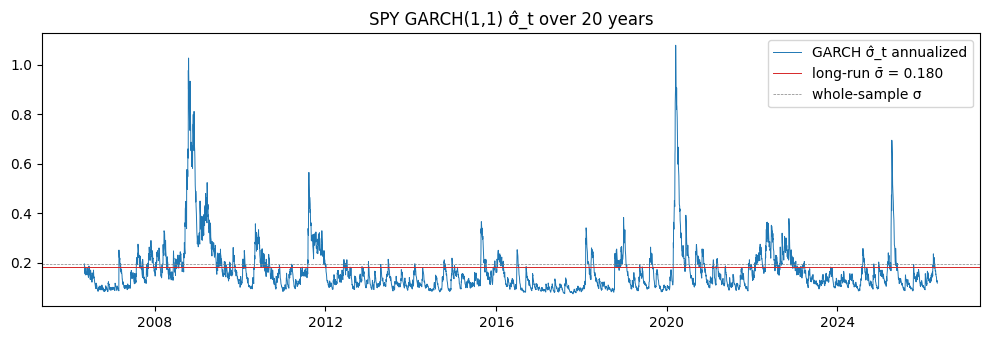

In [5]:
sigma_t_pct = np.sqrt(garch11_var_path(res.x, x_dem))
sigma_t = sigma_t_pct / 100  # decimal/day
sigma_series = pd.Series(sigma_t, index=spy_lr.index)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(sigma_series.index, sigma_series.values * np.sqrt(252), lw=0.7, label="GARCH σ̂_t annualized")
ax.axhline(lr_sigma_ann, color="C3", lw=0.7, label=f"long-run σ̄ = {lr_sigma_ann:.3f}")
ax.axhline(const_sigma * np.sqrt(252), color="gray", lw=0.5, ls="--", label=f"whole-sample σ")
ax.set_title("SPY GARCH(1,1) σ̂_t over 20 years"); ax.legend(); fig.tight_layout(); plt.show()

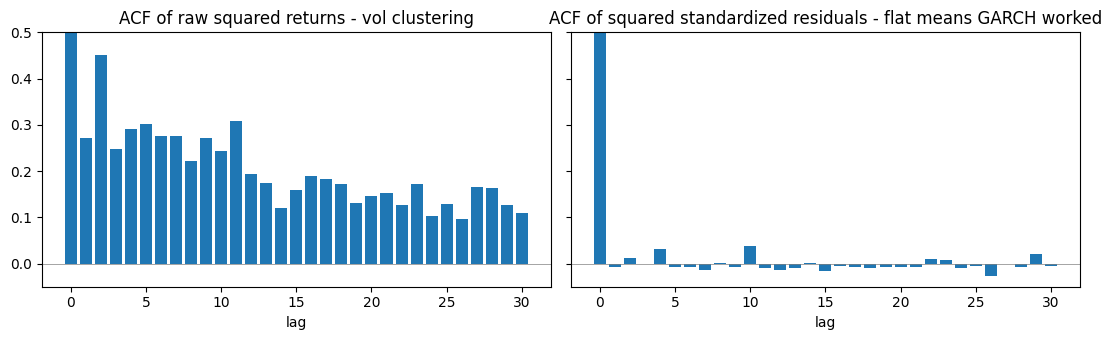

In [6]:
resid_std = (x_dem / 100) / sigma_t

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
axes[0].bar(range(31), acf(spy_lr.values ** 2, nlags=30, fft=True))
axes[0].axhline(0, color="gray", lw=0.5); axes[0].set_title("ACF of raw squared returns - vol clustering")
axes[1].bar(range(31), acf(resid_std ** 2, nlags=30, fft=True))
axes[1].axhline(0, color="gray", lw=0.5); axes[1].set_title("ACF of squared standardized residuals - flat means GARCH worked")
for a in axes: a.set_xlabel("lag"); a.set_ylim(-0.05, 0.50)
fig.tight_layout(); plt.show()

**Reading the GARCH fit.** α ≈ 0.14 means yesterday's shock² gets ~14% weight in today's variance forecast; β ≈ 0.84 means yesterday's forecast gets ~84% weight. Today's σ̂ is mostly a smooth update of yesterday's, with a 14% "kick" from yesterday's actual outcome — *exactly* what vol clustering looks like: persistent + reactive.

α + β ≈ 0.98 confirms high persistence; the GARCH(1,1) is **near-integrated** (α+β so close to 1 that vol shocks decay extremely slowly, on the edge of non-stationary). Long-run σ̄ ≈ 18.0% sits *below* whole-sample σ ≈ 19.5% — whole-sample σ is itself inflated by the same crisis tails GARCH absorbs into ω; the recursion partitions vol into a steady-state piece and a transient piece.

**The diagnostic ACF contrast (above) is the chapter's "GARCH worked" picture.** Raw squared returns show clear positive autocorrelation across many lags (lag-1 ≈ 0.27, lag-2 ≈ 0.45 — vol clustering). Squared *standardised* residuals are flat near zero (lag-1 ≈ 0.00, lag-2 ≈ 0.01) — the clustering has been absorbed.

## 5. GARCH-VaR — Ch5's parametric VaR with σ̂_t

Apply Ch5's parametric Gaussian VaR formula with the *conditional* σ̂<sub>t</sub> instead of constant σ̂:

> VaR<sub>t</sub>(q) = z<sub>q</sub> · σ̂<sub>t</sub>

For a $100k position, the dollar 5%-VaR on day *t* is $100,000 · 1.645 · σ̂<sub>t</sub>.

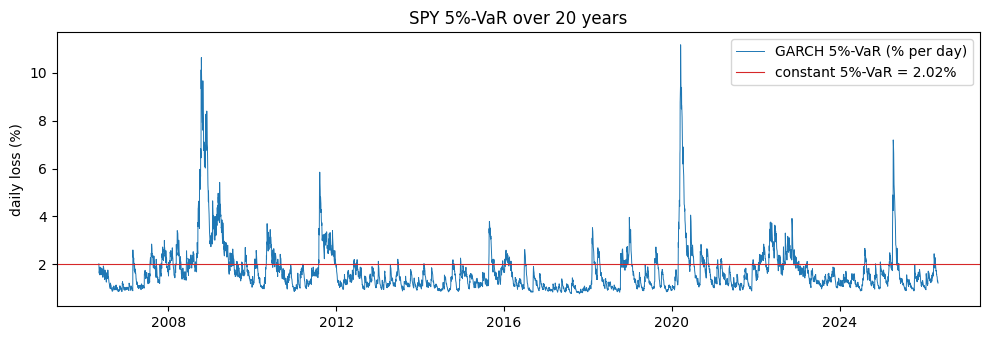

In [7]:
var_const = 1.645 * const_sigma
var_garch = 1.645 * sigma_series

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(var_garch.index, var_garch.values * 100, lw=0.7, label="GARCH 5%-VaR (% per day)")
ax.axhline(var_const * 100, color="C3", lw=0.8, label=f"constant 5%-VaR = {var_const*100:.2f}%")
ax.set_title("SPY 5%-VaR over 20 years"); ax.set_ylabel("daily loss (%)"); ax.legend()
fig.tight_layout(); plt.show()

In [8]:
events = {"GFC peak":      ("2008-09-15", "2008-12-31"),
          "COVID":         ("2020-02-15", "2020-04-30"),
          "2022 selloff":  ("2022-01-01", "2022-12-31")}
print(f"constant 5%-VaR baseline: {var_const*100:.3f}% per day  (= ${var_const * 100_000:.0f} on $100k)")
for name, (start, end) in events.items():
    win = var_garch.loc[start:end]
    ratio = win.max() / var_const
    print(f"{name:14s}: GARCH-VaR peak = {win.max()*100:.2f}%  (ratio {ratio:.2f}x baseline)")

constant 5%-VaR baseline: 2.015% per day  (= $2015 on $100k)
GFC peak      : GARCH-VaR peak = 10.64%  (ratio 5.28x baseline)
COVID         : GARCH-VaR peak = 11.18%  (ratio 5.55x baseline)
2022 selloff  : GARCH-VaR peak = 3.91%  (ratio 1.94x baseline)


**Three event windows.**

- **GFC peak (Sep-Dec 2008).** GARCH-VaR widens to ~5.3× the constant-σ baseline. The "$1,645 expected daily worst case" on $100k widens to about $8,700. The constant-σ assumption was *severely* wrong on those days — Ch5's parametric VaR was painting an entirely wrong picture of risk.
- **COVID (Mar-Apr 2020).** GARCH-VaR spikes to ~5.6× baseline within a week — the fastest spike in the 20-year window — and mean-reverts over months.
- **2022 selloff.** GARCH-VaR rises smoothly over the year, peaks at ~1.9× baseline. A slower, less extreme regime.

**Honest note:** GARCH-VaR is *conditionally Gaussian*. On tail-event days even the conditional distribution has fatter tails than Normal. So GARCH-VaR over-reads the 5% tail correctly but still under-estimates 0.1% / 0.05% deep-tail VaR even after fixing σ̂<sub>t</sub>. **Ch10 fixes this with EVT applied to standardised residuals (ε<sub>t</sub>/σ̂<sub>t</sub>)** — the right combination is "GARCH for the variance, EVT for the tail shape," known in production as **filtered historical simulation (FHS)**.

## 6. DCC-GARCH — time-varying correlations

DCC = Dynamic Conditional Correlation. Two steps:

1. **Fit per-asset GARCH** on each series; extract σ̂<sub>i,t</sub> and **standardise residuals**: z<sub>i,t</sub> = ε<sub>i,t</sub> / σ̂<sub>i,t</sub>. The z<sub>i,t</sub> are approximately unit-variance and i.i.d.-like (if the GARCH fits well).
2. **Update the correlation matrix as a GARCH-style recursion** on the standardised residuals:

> Q<sub>t</sub> = (1 − a − b) · Q̄ + a · z<sub>t-1</sub>z<sub>t-1</sub>ᵀ + b · Q<sub>t-1</sub>
>
> R<sub>t</sub> = diag(Q<sub>t</sub>)<sup>−1/2</sup> · Q<sub>t</sub> · diag(Q<sub>t</sub>)<sup>−1/2</sup>

Two extra parameters (a, b) fit by MLE under multivariate Gaussian. Same hand-rolled approach as the univariate GARCH above.

In [ ]:
# Per-asset GARCH first (each on the bivariate panel period)
zs = []
sigs = []
for col in ["SPY", "TLT"]:
    rp = (panel_lr[col] * 100).values
    rd = rp - rp.mean()
    res_i = minimize(garch11_neg_loglik, [0.02, 0.08, 0.90], args=(rd,), method="L-BFGS-B",
                     bounds=[(1e-8, None), (0, 0.5), (0, 0.999)])
    sig_i = np.sqrt(garch11_var_path(res_i.x, rd))
    zs.append(rd / sig_i); sigs.append(sig_i)
z = np.column_stack(zs)
T = len(z)
Q_bar = np.cov(z.T)

def dcc_recursion(params, z, Q_bar):
    a, b = params
    if a < 0 or b < 0 or a + b >= 1: return None, None
    Q = np.empty((T, 2, 2)); R = np.empty((T, 2, 2))
    Q[0] = Q_bar; R[0] = np.eye(2)
    for t in range(1, T):
        Q[t] = (1 - a - b) * Q_bar + a * np.outer(z[t-1], z[t-1]) + b * Q[t-1]
        d = np.sqrt(np.diag(Q[t]))
        R[t] = Q[t] / np.outer(d, d)
    return Q, R

def dcc_neg_ll(params, z, Q_bar):
    Q, R = dcc_recursion(params, z, Q_bar)
    if R is None: return 1e10
    ll = 0.0
    for t in range(1, len(z)):
        # closed-form 2x2 inverse to skip np.linalg.inv overhead inside the per-t loop
        det = R[t,0,0] * R[t,1,1] - R[t,0,1] ** 2
        if det <= 0: return 1e10
        inv = np.array([[R[t,1,1], -R[t,0,1]], [-R[t,0,1], R[t,0,0]]]) / det
        ll += np.log(det) + z[t] @ inv @ z[t]
    return ll

res_dcc = minimize(dcc_neg_ll, [0.04, 0.94], args=(z, Q_bar), method="L-BFGS-B",
                   bounds=[(1e-6, 0.5), (1e-6, 0.999)])
a_hat, b_hat = res_dcc.x
print(f"DCC fit: a = {a_hat:.4f}, b = {b_hat:.4f}, a+b = {a_hat + b_hat:.4f}")
_, R_t = dcc_recursion([a_hat, b_hat], z, Q_bar)
rho_t = pd.Series(R_t[:, 0, 1], index=panel_lr.index)
print(f"DCC ρ_t range: {rho_t.min():.3f} to {rho_t.max():.3f}")

In [ ]:
roll_corr = panel_lr["SPY"].rolling(60).corr(panel_lr["TLT"])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(roll_corr.index, roll_corr.values, lw=0.6, alpha=0.7, label="60-day rolling ρ (Ch3)")
ax.plot(rho_t.index, rho_t.values, lw=0.8, label="DCC ρ_t")
ax.axhline(0, color="gray", lw=0.5)
ax.set_title("SPY/TLT correlation - rolling vs DCC-GARCH")
ax.set_ylabel("ρ_t (conditional correlation)")
ax.legend(); fig.tight_layout(); plt.show()

**Reading the DCC plot.** DCC ρ̂<sub>t</sub> tracks the rolling 60-day correlation closely most of the time but reacts faster around regime shifts. Highlights:

- **2008-2009 (GFC).** DCC ρ stays deeply negative (min ≈ −0.70). Bonds were a strong hedge for stocks during the financial crisis — flight to quality.
- **2022 selloff.** DCC ρ flips into the positive range (max ≈ +0.32). The Fed's rate hikes hit bonds and stocks simultaneously; the multi-decade bond-stock hedge broke. **Ch3's promised sign flip, captured cleanly.**
- **DCC reaches new regimes faster than rolling-60.** When 2022 hit, rolling-60 took weeks to drift positive; DCC was already there in days.

> **Caveat: DCC scales to ~10 assets, not 100.** Beyond that the (a, b) MLE becomes brittle; correlation-target shrinkage helps but is out of scope.

## 7. Limits — five caveats

**1. Conditional Gaussian.** Real residuals are still fat-tailed even after standardising by σ̂<sub>t</sub>. **Ch10's EVT on standardised residuals** is the natural fix.

**2. Structural breaks.** GARCH assumes (ω, α, β) are constants. They're not — pre-2008 vs post-2020 fits differ; long windows average across regimes. (Exercise 2 measures this.)

**3. No regime prediction.** GARCH adapts *after the fact.* It cannot predict an upcoming spike; it can only update *during* one. The Feb 2020 σ̂ trajectory shows this: the model jumps *with* COVID, not before.

**4. DCC scale.** Beyond ~10 assets the (a, b) MLE becomes brittle.

**5. Backtest danger.** Fitting GARCH on the whole sample then "predicting" σ̂<sub>t</sub> is *in-sample*. Honest backtests refit on a rolling window. **Chapter 13** revisits this rigorously.

## 8. Recap

- **EWMA** — cheap, intuitive, no mean reversion. Use when you need a quick number.
- **GARCH(1,1)** — three parameters, MLE-fit, mean-reverting. The standard daily-equity vol model.
- **DCC-GARCH** — extends GARCH to multivariate; gives time-varying correlations.
- **Hidden lesson — MLE.** The most useful inferential tool we hadn't introduced; the only chapter that genuinely needs it. Hand-rolled in plain `scipy`.

## 9. So what?

**Decision rules:**

- **Use GARCH-σ for *today's* risk decisions.** Whole-sample σ is for benchmarking; today's GARCH-σ is for sizing.
- **Don't use raw GARCH-VaR for tail events.** Pair with EVT (**Ch10**).
- **Refit on a rolling window.** Don't fit once on 20y and use the parameters forever; structural breaks happen.
- **For correlations, EWMA-on-products is often as good as DCC at small scale** — and 100× faster. Use DCC when you have a story about why time-varying correlations matter for *this specific* decision.

**What this chapter can't yet tell you:**

- What to do about fat tails in residuals. **Ch10 EVT.**
- How to combine vol clustering with strategy signals. **Future Ch12.**
- How to backtest a GARCH-VaR system honestly. **Ch13.**
- How GARCH behaves at intraday frequencies. **Future Ch15.**

## Key Terms

| Term | Definition |
|---|---|
| EWMA | Exponentially-weighted moving average; closed-form vol recursion with decay parameter λ. |
| RiskMetrics | JP Morgan's 1996 technical document that made EWMA the industry-standard daily vol model. |
| GARCH(1,1) | σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}; one ARCH lag, one GARCH lag. |
| Stationarity | Statistical properties (mean, variance) don't drift over time; for GARCH(1,1), α + β < 1 ensures finite long-run variance. |
| Near-integrated | α + β so close to 1 that vol shocks decay extremely slowly, on the edge of non-stationary. |
| Conditional vs unconditional vol | Conditional = today's, given history; unconditional = whole-sample average. |
| Persistence (α + β) | Sum of GARCH coefficients; how slowly vol shocks decay. |
| Long-run / unconditional vol | σ̄ = √(ω/(1−α−β)); the GARCH-implied steady-state vol. |
| ARCH | Autoregressive Conditional Heteroskedasticity; GARCH's predecessor (named only). |
| MLE (Maximum Likelihood Estimation) | Pick parameters that make observed data most likely under the model. |
| Log-likelihood | Log of the joint density of the data under the model parameters; taking the log turns the product of densities into a sum (numerically stable, easier to differentiate). MLE picks the parameters that maximise it. |
| Standardised residual | ε_t / σ̂_t; should be approximately i.i.d. if the vol model captured everything. |
| DCC-GARCH | Dynamic Conditional Correlation; multivariate GARCH for time-varying ρ. |
| Structural break | Permanent shift in the data-generating process (e.g., COVID jump). |
| Regime (refresh from Ch2) | An extended period with stable parameters. |
| GARCH-VaR | Ch5's parametric VaR with σ̂_t in place of constant σ̂. |
| EGARCH (named) | Asymmetric GARCH variant capturing the leverage effect. |
| GJR-GARCH (named) | Another asymmetric GARCH variant. |

## Exercises

Try these in fresh cells below. Solutions are not provided — the goal is to consolidate the chapter's machinery on slightly different inputs.

1. **EWMA vs GARCH on a sector.** Refit both models on XLE (energy — high-vol, high-clustering). How do the σ̂<sub>t</sub> series differ? When does EWMA over-react vs GARCH? Are XLE's GARCH parameters similar to SPY's, or noticeably different?

2. **Persistence audit.** Refit GARCH(1,1) on SPY using the first 10y only, then the second 10y only. How do α, β, persistence change? What does that say about whether a single 20y fit is "the right" parameterisation for production use?

3. **GARCH-VaR at 1%.** Repeat the §5.2 backtest at 1% VaR. Does GARCH-VaR still hit nominal? Does constant-σ still under-breach? Why might the 1% level be more sensitive to the model choice than 5%?

4. *(stretch)* **DCC on three assets.** Add GLD to the SPY/TLT pair. Fit DCC on the three-asset panel. How does SPY/GLD behave around 2008-09 and 2020 vs SPY/TLT? Does GLD's "flight-to-quality" pattern look like TLT's, or different in shape?


End of notebook. Read the chapter [`README.md`](./README.md) for the canonical narrative.